# Split - Apply - Combine

In [3]:
import pandas as pd
import numpy as np

# 데이터 읽어오기

In [6]:
# payment_df = pd.read_csv("./sakila/payment.csv")
# customer_df = pd.read_csv("./sakila/customer.csv")
payment_df = pd.read_csv(r'/Users/leo/LeoData/MyCode/KoreaITAcademy/LangChain/dataset/mysql/sakila/payment.csv')
customer_df = pd.read_csv(r'/Users/leo/LeoData/MyCode/KoreaITAcademy/LangChain/dataset/mysql/sakila/customer.csv')

### 데이터 탐색하기

In [7]:
customer_df.head()

,customer_id,store_id,first_name,last_name,email,address_id,active,create_date,last_update
0,1,1,MARY,SMITH,MARY.SMITH@sakilacustomer.org,5,1,2006-02-14 22:04:36,2006-02-15 04:57:20
1,2,1,PATRICIA,JOHNSON,PATRICIA.JOHNSON@sakilacustomer.org,6,1,2006-02-14 22:04:36,2006-02-15 04:57:20
2,3,1,LINDA,WILLIAMS,LINDA.WILLIAMS@sakilacustomer.org,7,1,2006-02-14 22:04:36,2006-02-15 04:57:20
3,4,2,BARBARA,JONES,BARBARA.JONES@sakilacustomer.org,8,1,2006-02-14 22:04:36,2006-02-15 04:57:20
4,5,1,ELIZABETH,BROWN,ELIZABETH.BROWN@sakilacustomer.org,9,1,2006-02-14 22:04:36,2006-02-15 04:57:20


In [9]:
customer_df.shape

(599, 9)

In [10]:
customer_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 599 entries, 0 to 598
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   customer_id  599 non-null    int64
 1   store_id     599 non-null    int64
 2   first_name   599 non-null    str  
 3   last_name    599 non-null    str  
 4   email        599 non-null    str  
 5   address_id   599 non-null    int64
 6   active       599 non-null    int64
 7   create_date  599 non-null    str  
 8   last_update  599 non-null    str  
dtypes: int64(4), str(5)
memory usage: 90.1 KB


# Split
groupby()

In [26]:
group = payment_df.groupby("customer_id")  # 고객별로 쪼개기

# ↑ 이번단원에서 group 변수는 계속 사용할 것이다 ★

In [27]:
group.size()  # 구매를 한 customer_id의 수 만큼 그룹 생성

customer_id
1      32
2      27
3      26
4      22
5      38
       ..
595    30
596    28
597    25
598    22
599    19
Length: 599, dtype: int64

In [13]:
len(payment_df.customer_id.unique())

599

# 1. 고객별 주문량(amount) 횟수와 합계

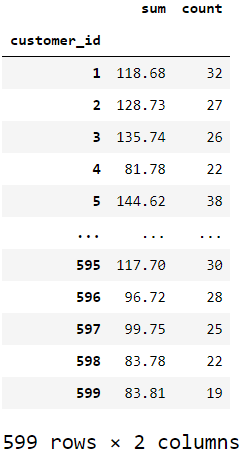

In [31]:
group['customer_id'].get_group(1)

0     1
1     1
2     1
3     1
4     1
5     1
6     1
7     1
8     1
9     1
10    1
11    1
12    1
13    1
14    1
15    1
16    1
17    1
18    1
19    1
20    1
21    1
22    1
23    1
24    1
25    1
26    1
27    1
28    1
29    1
30    1
31    1
Name: customer_id, dtype: int64

,customer_id,store_id,first_name,last_name,email,address_id,active,create_date,last_update_x,payment_id,staff_id,rental_id,amount,payment_date,last_update_y
0,1,1,MARY,SMITH,MARY.SMITH@sakilacustomer.org,5,1,2006-02-14 22:04:36,2006-02-15 04:57:20,1,1,76,2.99,2005-05-25 11:30:37,2006-02-15 22:12:30
1,1,1,MARY,SMITH,MARY.SMITH@sakilacustomer.org,5,1,2006-02-14 22:04:36,2006-02-15 04:57:20,2,1,573,0.99,2005-05-28 10:35:23,2006-02-15 22:12:30
2,1,1,MARY,SMITH,MARY.SMITH@sakilacustomer.org,5,1,2006-02-14 22:04:36,2006-02-15 04:57:20,3,1,1185,5.99,2005-06-15 00:54:12,2006-02-15 22:12:30
3,1,1,MARY,SMITH,MARY.SMITH@sakilacustomer.org,5,1,2006-02-14 22:04:36,2006-02-15 04:57:20,4,2,1422,0.99,2005-06-15 18:02:53,2006-02-15 22:12:30
4,1,1,MARY,SMITH,MARY.SMITH@sakilacustomer.org,5,1,2006-02-14 22:04:36,2006-02-15 04:57:20,5,2,1476,9.99,2005-06-15 21:08:46,2006-02-15 22:12:30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16039,599,2,AUSTIN,CINTRON,AUSTIN.CINTRON@sakilacustomer.org,605,1,2006-02-14 22:04:37,2006-02-15 04:57:20,16045,1,14599,4.99,2005-08-21 17:43:42,2006-02-15 22:24:12
16040,599,2,AUSTIN,CINTRON,AUSTIN.CINTRON@sakilacustomer.org,605,1,2006-02-14 22:04:37,2006-02-15 04:57:20,16046,1,14719,1.99,2005-08-21 21:41:57,2006-02-15 22:24:12
16041,599,2,AUSTIN,CINTRON,AUSTIN.CINTRON@sakilacustomer.org,605,1,2006-02-14 22:04:37,2006-02-15 04:57:20,16047,2,15590,8.99,2005-08-23 06:09:44,2006-02-15 22:24:12
16042,599,2,AUSTIN,CINTRON,AUSTIN.CINTRON@sakilacustomer.org,605,1,2006-02-14 22:04:37,2006-02-15 04:57:20,16048,2,15719,2.99,2005-08-23 11:08:46,2006-02-15 22:24:13


In [14]:
customer_df.head()

,customer_id,store_id,first_name,last_name,email,address_id,active,create_date,last_update
0,1,1,MARY,SMITH,MARY.SMITH@sakilacustomer.org,5,1,2006-02-14 22:04:36,2006-02-15 04:57:20
1,2,1,PATRICIA,JOHNSON,PATRICIA.JOHNSON@sakilacustomer.org,6,1,2006-02-14 22:04:36,2006-02-15 04:57:20
2,3,1,LINDA,WILLIAMS,LINDA.WILLIAMS@sakilacustomer.org,7,1,2006-02-14 22:04:36,2006-02-15 04:57:20
3,4,2,BARBARA,JONES,BARBARA.JONES@sakilacustomer.org,8,1,2006-02-14 22:04:36,2006-02-15 04:57:20
4,5,1,ELIZABETH,BROWN,ELIZABETH.BROWN@sakilacustomer.org,9,1,2006-02-14 22:04:36,2006-02-15 04:57:20


In [15]:
payment_df.head()

,payment_id,customer_id,staff_id,rental_id,amount,payment_date,last_update
0,1,1,1,76,2.99,2005-05-25 11:30:37,2006-02-15 22:12:30
1,2,1,1,573,0.99,2005-05-28 10:35:23,2006-02-15 22:12:30
2,3,1,1,1185,5.99,2005-06-15 00:54:12,2006-02-15 22:12:30
3,4,1,2,1422,0.99,2005-06-15 18:02:53,2006-02-15 22:12:30
4,5,1,2,1476,9.99,2005-06-15 21:08:46,2006-02-15 22:12:30


# 2. 결제횟수가 가장 많은 상위 유저 10명
- customer_id, 이메일, 결제금액, 결제횟수  출력

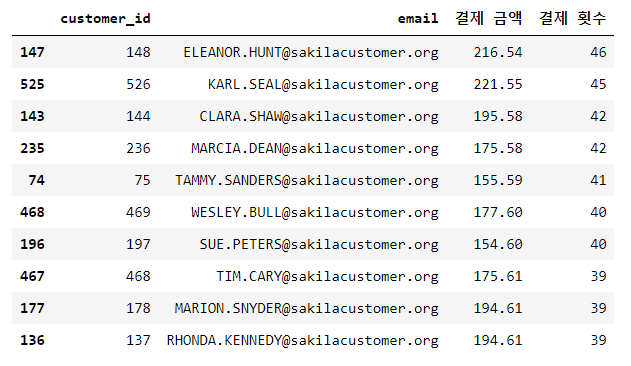

In [7]:
# TODO

# Split - Apply - Combine 전략

In [17]:
# SPLIT - APPLY - COMBINE
#  각각의 함수들이 '어떠한 input' 을 받아서 '어떠한 output' 을 내는지
#  정확하게 아는 것이 중요하다.

# ★ 이 함수들은 groupby() 의 결과물은 DataFrameGroupBy 객체의 함수들이다 ★

# APPLY 하는 함수 4가지 

# 1. .aggregate() / .agg() ( 집계하는 연산 )
#
#     <input>     <output>
# [1, 2, 3, 4] => 10(sum), 2.5(mean)
# 그룹(1, 2), 그룹(3, 4)    => [3, 7](sum), [1.5, 3.5](mean)  두개씩 묶는 다면.
#
#     <input>     <output>
# 데이터 갯수: N => 1개 

# 2. .transform() ( 데이터를 변형하는 연산 )
# x[1, 2, 3, 4] => [10, 10, 10, 10] (sum)
#                 [2.5, 2.5, 2.5, 2.5] (mean)
#                 [-1.5, -0.5, 0.5, 1.5]  ( x - mean ) 원본 - 평균연산.
#                 [0, 1, 2, 3]   데이터의 순서를 매기는 연산

# 3. .apply()
# [1, 2, 3, 4] => 10(sum)
#              => [4, 3, 2] ( 상위의 3개만 뽑자 )
# 데이터 갯수: N => 1(agg), N(transform), M(apply)
#
# ※ 사실 apply() 만 제대로 알면  위의 agg(), transform() 도 apply() 로 구현 가능

# 4. filter() ( 조건에 맞는 것만 걸러내는 연산 )
# payment_df 유저별 결제 횟수 ( 16000개 )
# 결제횟수가 30회 이상인 유저들에 대해서만, 결제 내역들을 전부 뽑자
# 16000(N) => 5000개(N>=)
#
#    <input>      <output>
# 데이터 갯수: N => N보다 같거나 적은 

# 3.결제 횟수가 30번 이상인 유저들의 결제 내역

[결과예시]
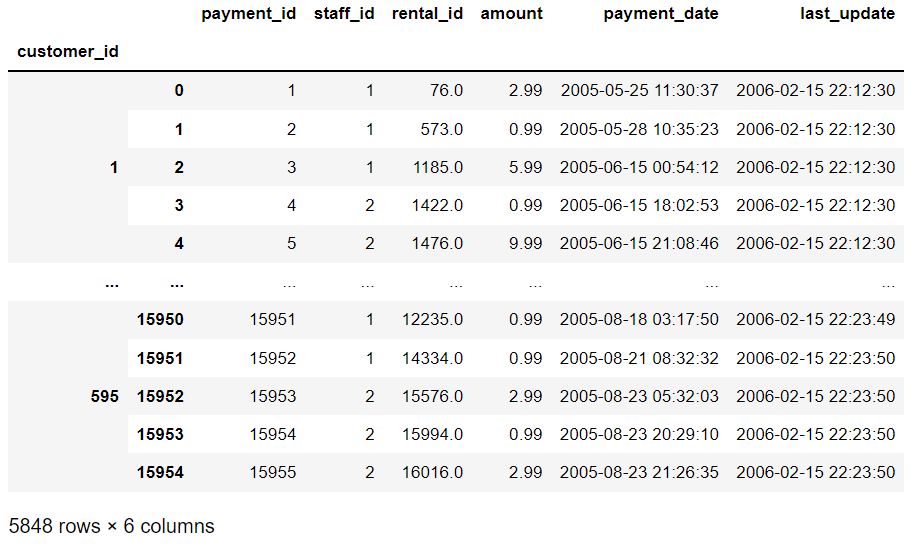

In [11]:
# hint)
# ① filter() 를 사용한 방법 
# ② apply() 를 사용한 방법

In [10]:
# TODO



# 4.도전: 고객별 첫 구매내역
- payment.csv 에서 payment_date 순으로 기록 되어 있다
- hint : apply() 사용

[결과예시]
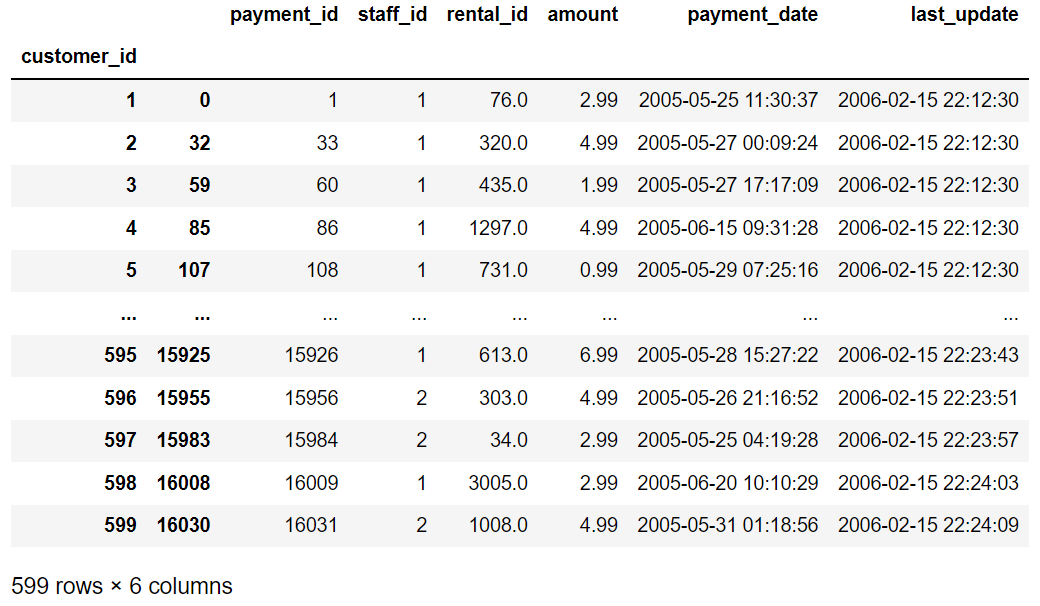

In [12]:
# TODO


## 5. 도전 : 유저별 최근 3개 구매 내역
- hint: apply() 

[결과예시]
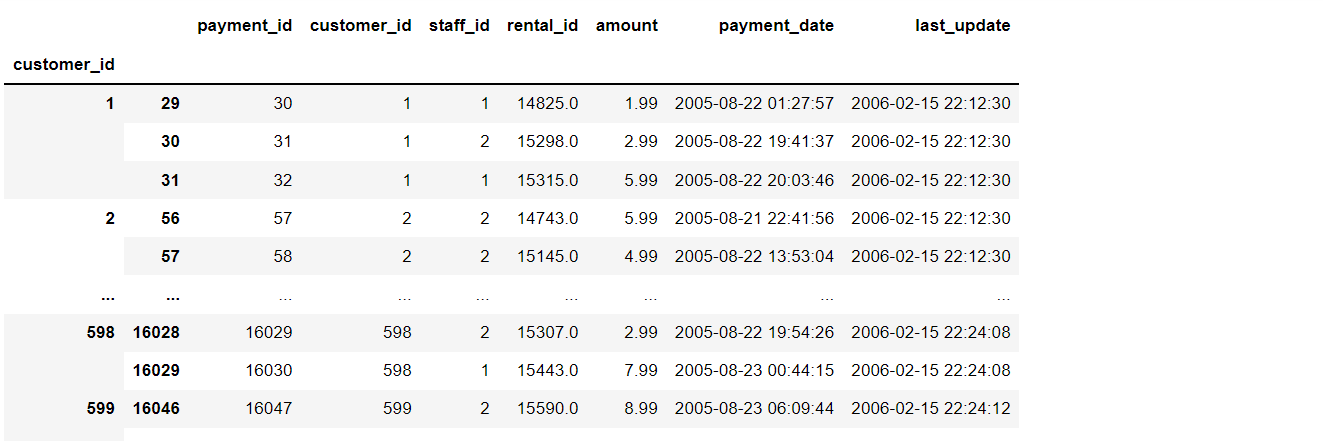

In [14]:
# TODO

# 6. 고객별 첫구매일/마지막 구매일

In [35]:
# 두가지 방법으로 만들어 볼거다
# 1) agg() 를 사용
# 2) apply() 를 사용

[결과예시]
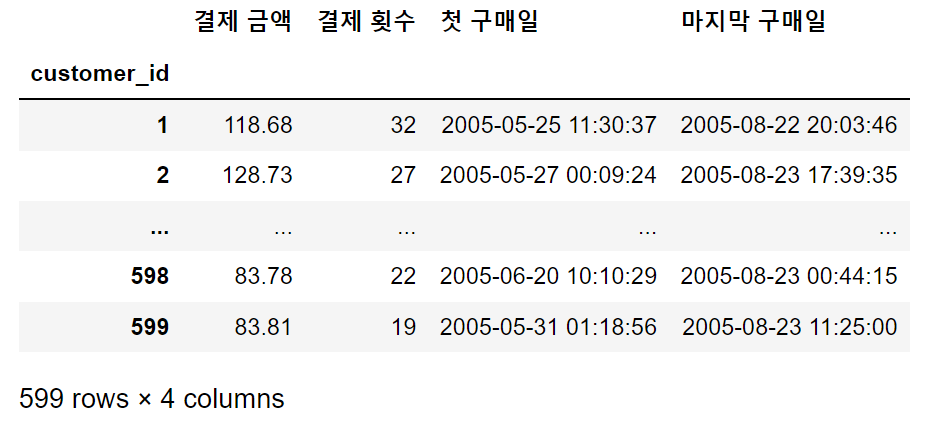

In [15]:
# TODO


# 7. 유저별 x 월별 집계

[결과예시]
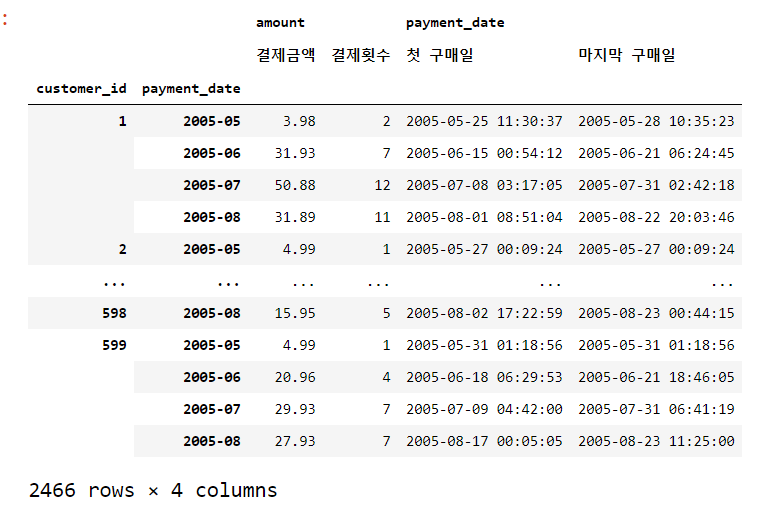

In [44]:
# 어떻게 그룹을 나눌까? 어떻게 연산을 적용할까?
# 좀더 복잡한 예제

In [ ]:
# 다음과 같은 결과를 뽑아내려면 어떻게 해야 할까?

# 유저별(1), 월별(5, 6, 7월)
# 결제횟수, 결제금액, 첫/마지막 구매일

# 위 문제는 DB로 해도 좀 어려울수 있습니다.

In [16]:
# hint) groupby(  기준 )  을 달리 해야 한다

In [17]:
# TODO



# 8.각 결제 내역이 결제한 유저의  평균 결제 금액보다 얼마나 큰가/작은가
- ① transform() 사용
- ② apply() 사용

[결과예시]
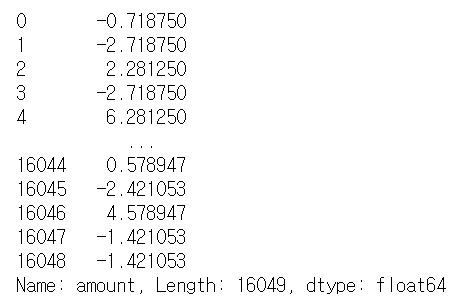

In [18]:
# TODO